![](img/logo.288981a8dfa8.png)

# Python Visualization for Exploration of Data

In this lesson we will investigate methods for the exploration of data using visualization techniques. We will use several Python packages to create the  visualizations, ```matplotlib```, ```Pandas``` plotting.  

For these lessons we will be working with a data set containing the prices and characteristics of a number of automobiles. The ultimate goal is to build a model for predicting the price of a car from its characteristics.


## Why visualization and Exploratory Data Analysis?

Visualization is an essential method in any data scientist’s toolbox. Visualization is a key first step in the exploration of most data sets. These process exploring data visually and with simple summary statistics is know as Exploratory Data Analysis (EDA).    

As a general rule, you should never start creating analytical or machine learning models until you have examined the data and understand the relationships. Otherwise, you risk wasting your time creating models blindly.

Visualization is also a powerful tool for presentation of results and for determining sources of problems with analytics.

The key concept of exploratory data analysis (EDA) or visual exploration of data is to understand the relationships in the data set. Specifically using visualization when you approach a new data set you can:

- Explore complex data sets, using visualization to develop understanding of the inherent relationships.
- Use different chart types to create multiple views of data to highlight different aspects of the inherent relationships.
- Use plot aesthetics to project multiple dimensions.
- Apply conditioning or faceting methods to project multiple dimensions



These lessons are divided into three parts. In each part you will learn how to use the visualization tools availble in Python.

- **Overview of plot types** is a reivew of creating basic plot types used to construct visualizations.
- **Using Aesthetics** is an overview of how to project additional plot dimensions using plot aesthetics.
- **Facetted plotting** also know as conditioned plotting or lattice plotting introduces a powerful method for visualizing higher dimensional data.

In these exercises, you will use ```matplotlib```, ```Pandas``` plotting, and the ```Seaborn``` package. We assume you have at least a bit of experience using Pandas and Jupyter notebooks.  


## Load and examine the data set

Let's get started. The function shown in the cell below loads the data from the .csv file. Some minimal clean up is performed on the data. Rows with missing values are dropped and some columns are converted from strings containing numbers to numeric data.

Execute the code in this cell to load the data into your notebook. **Make sure you have the .csv file in your working directory!**

In [3]:
def read_auto_data(fileName = "automobile-prices.csv"):
    'Function to load the auto price data set from a .csv file'
    import pandas as pd
    import numpy as np

    ## Read the .csv file with the pandas read_csv method
    auto_prices = pd.read_csv(fileName)

    ## Remove rows with missing values, accounting for mising values coded as '?'
    cols = ['price', 'bore', 'stroke',
          'horsepower', 'peak-rpm']
    for column in cols:
        auto_prices.loc[auto_prices[column] == '?', column] = np.nan
    auto_prices.dropna(axis = 0, inplace = True)

    ## Convert some columns to numeric values
    for column in cols:
        auto_prices[column] = pd.to_numeric(auto_prices[column])
#    auto_prices[cols] = auto_prices[cols].as_type(int64)

    return auto_prices
auto_prices = read_auto_data()

Using the Pandas ``head`` method let's have a first look at the columns in this data set.

In [4]:
auto_prices.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


You can see there are both numerical and string (categorical) variable types. As a next step examine some summary statistics of the numeric columns using the Pandas ``describe`` method. Note that units of measurement are American not Metric.  

In [5]:
auto_prices.describe()

,symboling,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
count,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000
mean,0.794872,98.896410,174.256923,65.886154,53.861538,2559.000000,127.938462,3.329385,3.250308,10.194974,103.271795,5099.487179,25.374359,30.841026,13248.015385
std,1.230612,6.132038,12.476443,2.132484,2.396778,524.715799,41.433916,0.271866,0.314115,4.062109,37.869730,468.271381,6.401382,6.829315,8056.330093
min,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,0.000000,94.500000,166.300000,64.050000,52.000000,2145.000000,98.000000,3.150000,3.110000,8.500000,70.000000,4800.000000,19.500000,25.000000,7756.500000
50%,1.000000,97.000000,173.200000,65.400000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5100.000000,25.000000,30.000000,10245.000000
75%,2.000000,102.400000,184.050000,66.900000,55.650000,2943.500000,145.500000,3.590000,3.410000,9.400000,116.000000,5500.000000,30.000000,35.000000,16509.000000
max,3.000000,120.900000,208.100000,72.000000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,262.000000,6600.000000,49.000000,54.000000,45400.000000


## Basic chart types

Now that we have loaded and had a first look at the data, let's get to work making some charts.

There are enumerable chart types that are used for data exploration. In this tutorial we focus on the most used chart types:

- **Scatter plot**
- **Line plots**
- **Bar plots**
- **Histograms**
- **Box plots**
- **Kernel Density Estimation Plots**
- **Violin plots**

### Scatter plots

Scatter plots show the relationship between two variables in the form of dots on the plot. In simple terms, the values along a horizontal axis are plotted against a vertical axis.

#### Scatter plots with Matplotlib

Matplotlib is at the base of most Python plotting packages. Some basic understanding of Matplotlib will help you achieve better control of your graphics.

Let's start by making a simple scatter plot. Our recipe is simple:

- Import Matplotlib.pyplot
- Use the plot method.
- Specify the values to plot on the x and y axes.
- Specify that we want red dots using a type of 'ro'. If you do not specify a type, you will get a line plot which is the default.

Exectute the code in the cell below to create a scatter plot of city mpg vs. auto price.

***
**Note:** The IPyhon magic command `%matplotlib inline` enables the display of graphics inline with the Python code. If you do not include this command your graphs will not be displayed.
***

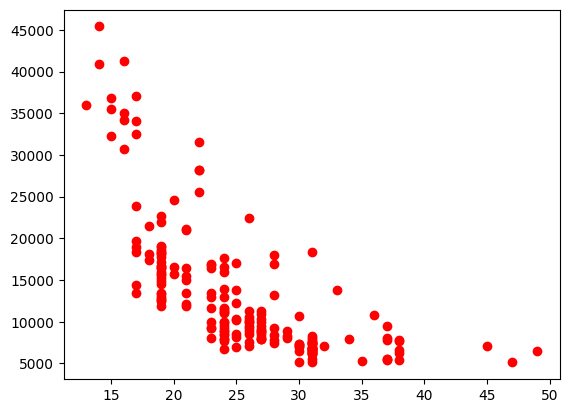

In [6]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.plot(auto_prices['city-mpg'], auto_prices['price'], 'ro')

So far so good. However, this plot is rather limited in several respects. Can you see some obvious deficiencies in this plot?

#### Scatter plots with Pandas

While you can create most any visualization using Matplotlib, with enough code, you may want a simpler approach if your data are in a Pandas data frame. The Pandas package contains a number of useful plot methods which operate on data frames. The simple recipe for plotting from Pandas data frames is:

- Use the plot method, specifing the ``kind`` argument, or use a chart-specific plot method.
- Specify the columns with the values for the ``x`` and ``y`` axes.

<Axes: xlabel='city-mpg', ylabel='price'>

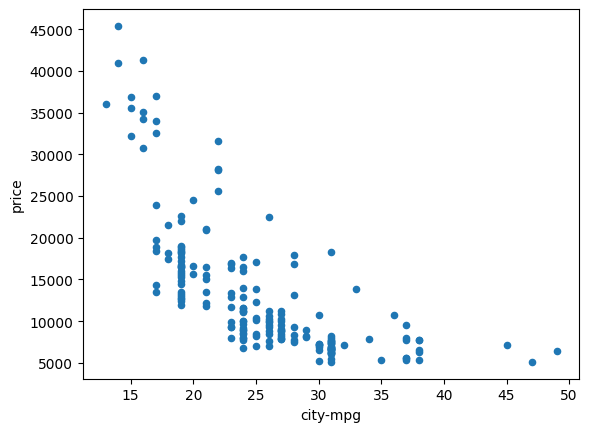

In [7]:
auto_prices.plot(kind = 'scatter', x = 'city-mpg', y = 'price')

The Pandas plotting method provides some nice improvements compared to the basic Matplotlib plot. Namely, the axes are scaled a bit better, so that points are not cut off, and some sensible axis labels are generated.

***
**Your turn:** In the cell below create and exectue code to plot auto price vs curb weight.
***

<Axes: xlabel='curb-weight', ylabel='price'>

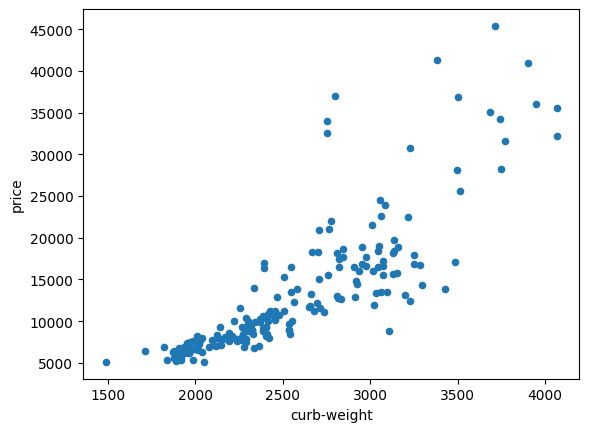

In [8]:
auto_prices.plot(kind = 'scatter', x = 'curb-weight', y = 'price')

Our basic recipe worked, but it does not give us much control over the result. We can take advantage of the fact that Pandas plot methods are built on matplotlib. Thus, we can specify a figure and one or more axes within that figure. Then, we can control many plot attributes once we have specified the axes. Our improved recipe looks like this:

- Specify a figure, including a size.
- Define one or more axes within the figure.
- Use the pandas plot method of choice. Make sure you specify the axis you are using.
- Use methods on the axes to control and add attributes like titles and axis labels.

Text(0, 0.5, 'Auto Price')

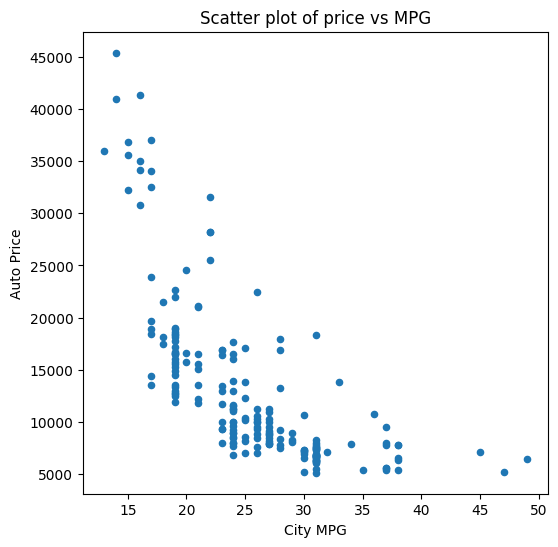

In [9]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(6, 6)) # define plot area
ax = fig.gca() # define axis
auto_prices.plot(kind = 'scatter', x = 'city-mpg', y = 'price', ax = ax)
ax.set_title('Scatter plot of price vs MPG') # Give the plot a main title
ax.set_xlabel('City MPG') # Set text for the x axis
ax.set_ylabel('Auto Price')# Set text for y axis

In the plot above, we can see that the most costly cars have the lowest fuel efficiency, whereas relatively inexpensive cars are also more economical to drive.

***
**Your turn:** In the cell below, ceate and execute the code required to display an improved version of the plot you created in the pervious exercise. Specify the plot size, and make sure to include axis lables and a main title.

Text(0, 0.5, 'Auto Price')

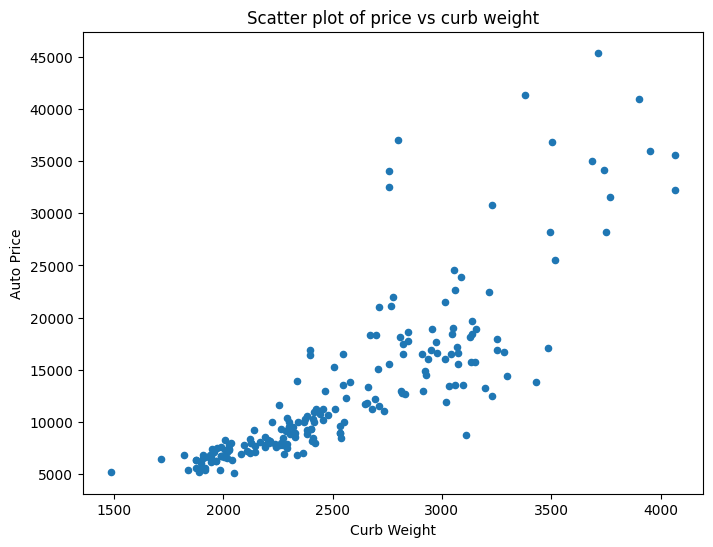

In [10]:
fig = plt.figure(figsize=(8, 6)) # define plot area
ax = fig.gca() # define axis
auto_prices.plot(kind = 'scatter', x = 'curb-weight', y = 'price', ax = ax)
ax.set_title('Scatter plot of price vs curb weight') # Give the plot a main title
ax.set_xlabel('Curb Weight') # Set text for the x axis
ax.set_ylabel('Auto Price')# Set text for y axis

### Line plots

Line plots are similar to point plots. In line plots the discrete points are connected by lines.

First, we will create a dataframe, with a simple relationship between x and y.

In [11]:
import pandas as pd
x = list(range(100))
y = [z * z for z in range(100)]
df = pd.DataFrame({'x':x, 'y':y})

Now, apply the previous recipe to plot x vs y as a line chart.

Text(0, 0.5, 'x^2')

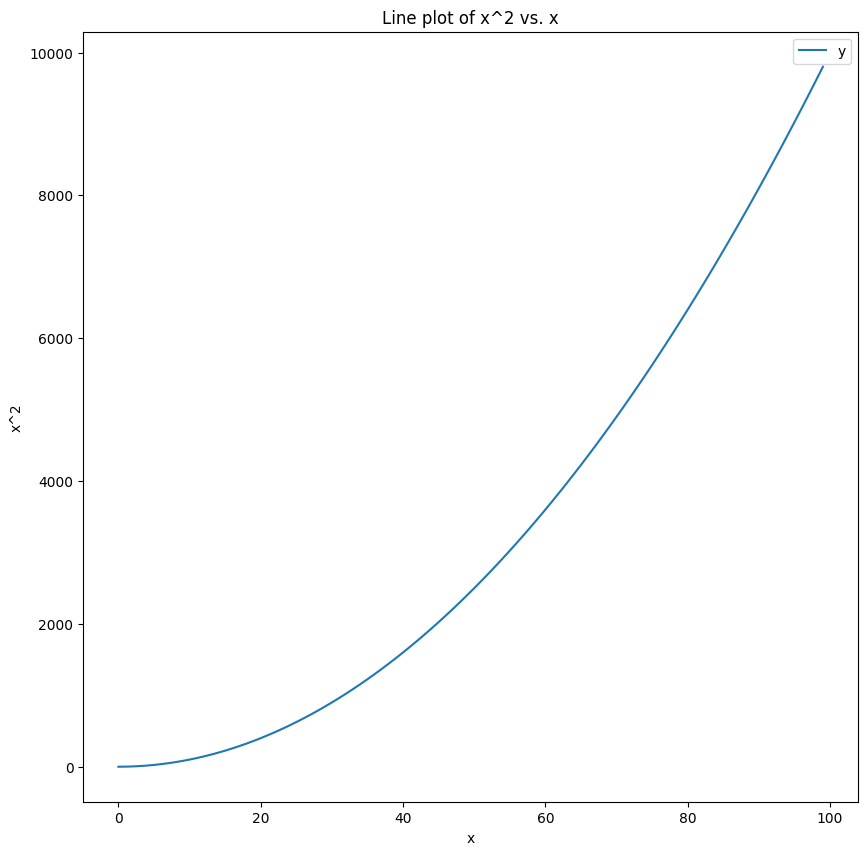

In [12]:
fig = plt.figure(figsize=(10, 10)) # define plot area
ax = fig.gca() # define axis
df.plot(x = 'x', y = 'y', ax = ax) ## line is the default plot type
ax.set_title('Line plot of x^2 vs. x') # Give the plot a main title
ax.set_xlabel('x') # Set text for the x axis
ax.set_ylabel('x^2')# Set text for y axis

### Bar plots

Bar plots are used to display the counts of unique values of a categorical variable. The height of the bar represents the count for each unique category of the variable.

It is unlikely that your pandas data frame includes counts by category of a variable. Thus, the first step in making a bar plot is to compute the counts. Fortunately, pandas has a ``value_counts`` method. The code below uses this method to create a new data frame containing the counts by ``make`` of the car.

In [13]:
counts = auto_prices['make'].value_counts() # find the counts for each unique category
counts

,count
make,
toyota,32
nissan,18
mitsubishi,13
honda,13
mazda,13
volkswagen,12
subaru,12
volvo,11
peugot,11


You can see the ordered list of counts by make above. Notice that this data frame has many fewer rows than the original, since it only needs one row for each unique value of the make.

Now, create the bar plot of number of autos by make using the ``counts`` data frame, by executing the code in the cell below. Notice, that the recipe for this chart is the same as we have used for scatter plots and line plots, just using the ``.plot.bar`` method.

Text(0, 0.5, 'Number of autos')

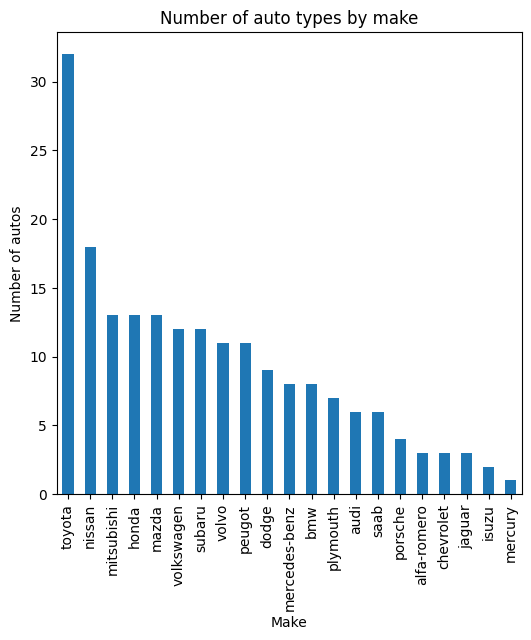

In [14]:
fig = plt.figure(figsize=(6,6)) # define plot area
ax = fig.gca() # define axis
counts.plot.bar(ax = ax) # Use the plot.bar method on the counts data frame
ax.set_title('Number of auto types by make') # Give the plot a main title
ax.set_xlabel('Make') # Set text for the x axis
ax.set_ylabel('Number of autos')# Set text for y axis

The bar plot clearly shows which auto manufacturers have the largest number of models. The more specialized makes have relatively fewer models.

### Histograms

Histograms are related to bar plots. Histograms are used for numeric variables. Whereas, a bar plot shows the counts of unique categories, a histogram shows the number of data with values within a bin. The bins divide the values of the variable into equal segments. The vertical axis of the histogram shows the count of data values within each bin.  

The code below follows our same basic recipe to create a histogram of ``engine-size``. Notice however, that the column of the data frame we wish to plot is specified by name as ``auto_prices['engine-size']``.

Text(0, 0.5, 'Number of autos')

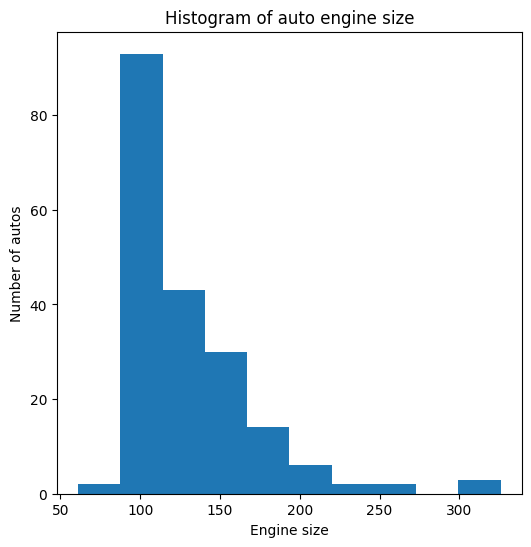

In [15]:
fig = plt.figure(figsize=(6,6)) # define plot area
ax = fig.gca() # define axis
auto_prices['engine-size'].plot.hist(ax = ax) # Use the plot.hist method on subset of the data frame
ax.set_title('Histogram of auto engine size') # Give the plot a main title
ax.set_xlabel('Engine size') # Set text for the x axis
ax.set_ylabel('Number of autos')# Set text for y axis

The histogram shows that the distibution of engine size is skewed toward small engines. There are also a few autos with very large engines, which appear as outliers.

### Box plots

Box plots, also known as box and wisker plots, were introduced by John Tukey in 1970. Box plots are another way to visualize the distribution of data values. In this respect, box plots are comparable to histograms, but are quite different in presentation.

On a box plot the median value is shown with a dark bar. The inner two quartiles of data values are contained within the 'box'. The 'wiskers' enclose the majority of the data (up to +/- 2.5 * interquartile range). Outliers are shown by symbols byond the wiskers.

Several box plots can be stacked along an axis for comparison. The data are divided using a 'group by' operation, and the box plots for each group are stacked next to each other. In this way, the box plot allows you to display two dimensions of your data set.

The code in the cell below generally follows the recipe we have been using. The data frame is subsetted to two columns. One column contains the numeric values to plot and the other column is the group by variable. In this case, the group by variable is specified with the ``by = 'fuel-type'`` argument.

Text(0, 0.5, 'Engine size')

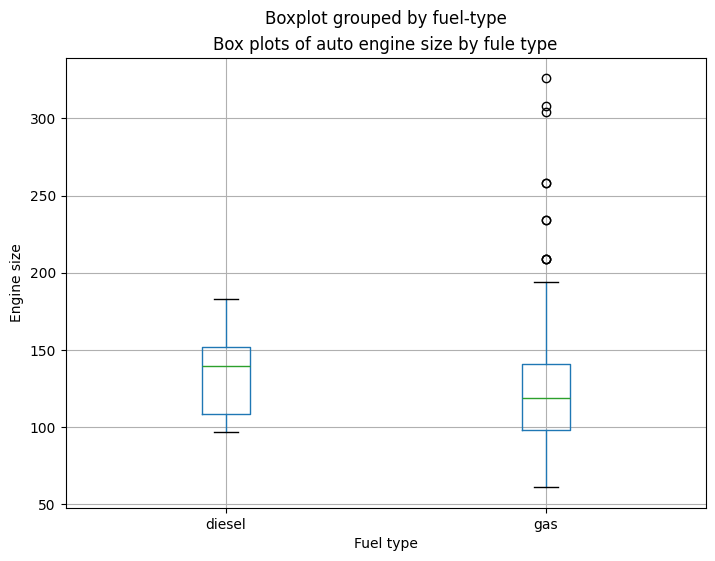

In [16]:
fig = plt.figure(figsize=(8,6)) # define plot area
ax = fig.gca() # define axis
auto_prices[['engine-size','fuel-type']].boxplot(by = 'fuel-type', ax = ax) # Use the plot.bar method on the new data frame
ax.set_title('Box plots of auto engine size by fule type') # Give the plot a main title
ax.set_xlabel('Fuel type') # Set text for the x axis
ax.set_ylabel('Engine size')# Set text for y axis